Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital\
**Tecnología Digital VI: Inteligencia Artificial**

# **Convoluciones traspuestas**

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(0)

In [3]:
def show_matrix(matrix):
    plt.rcParams['figure.figsize'] = [7.50, 3.50]
    plt.rcParams['figure.autolayout'] = True

    plt.rcParams['text.color'] = '#ff2222'

    fig, ax = plt.subplots()
    min_val, max_val = 0, matrix.shape[1]
    ax.matshow(matrix, cmap = 'viridis')

    for i in range(max_val):
        for j in range(max_val):
            c = matrix[j, i]
            ax.text(i, j, str(c.item()), va = 'center', ha = 'center')

    plt.show()

### **Convolución con pesos especificados "a mano"**

In [4]:
weights = torch.tensor([[[0., 0.], [0., 1.]],
                         [[1., 0.], [0., 0.]]])

conv_kernels = weights.unsqueeze(0)

print(conv_kernels.shape)

torch.Size([1, 2, 2, 2])


In [5]:
# Creamos una imagen de 2 canales (por ejemplo, escala de grises con un canal adicional de transparencia).
input_image = torch.randint(0, 10, (2, 3, 3)).float()
input_image = input_image.unsqueeze(0) # Batch size.

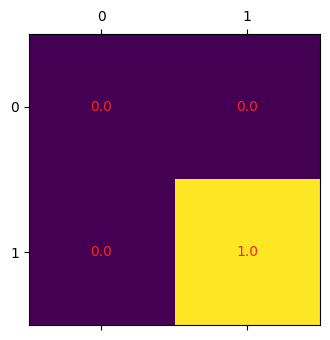

In [6]:
# Inspeccionamos el primer kernel.
show_matrix(weights[0])

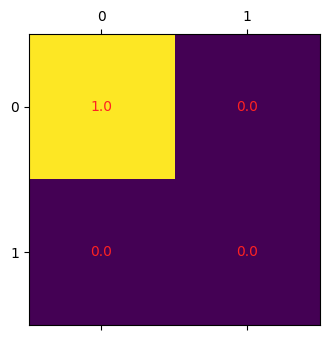

In [7]:
# Inspeccionamos el segundo kernel.
show_matrix(weights[1])

In [8]:
input_image[0]

tensor([[[4., 9., 3.],
         [0., 3., 9.],
         [7., 3., 7.]],

        [[3., 1., 6.],
         [6., 9., 8.],
         [6., 6., 8.]]])

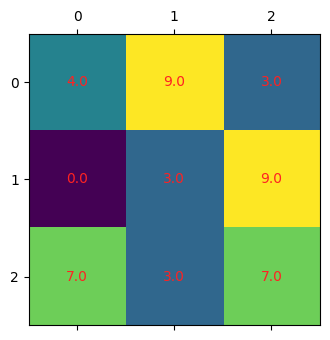

In [9]:
# El primer canal del input.
show_matrix(input_image[0][0])

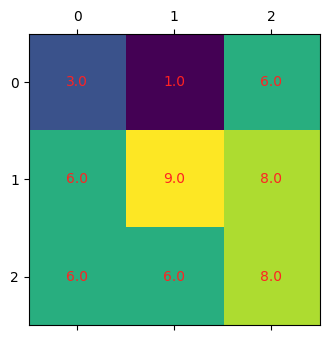

In [10]:
# El segundo canal del input.
show_matrix(input_image[0][1])

In [11]:
output = F.conv2d(input_image, conv_kernels, stride=1, padding = 0)

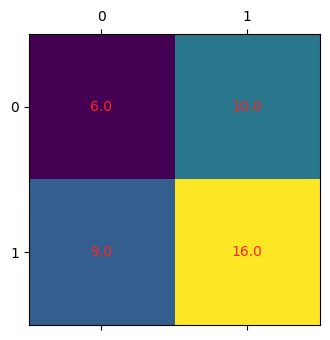

In [12]:
# Vemos cómo se ve el output.
show_matrix(output[0][0])

### **Convolución traspuesta con pesos especificados "a mano"**

Ahora, estamos usando DOS kernels *deconvolucionales*. Por lo tanto, la salida tendrá dos canales.

In [13]:
deconv_weights = torch.tensor([[[0., 0.], [0., 1.]],
                               [[1., 0.], [0., 0.]]])

deconv_kernels = deconv_weights.unsqueeze(0)

print(deconv_kernels.shape)

torch.Size([1, 2, 2, 2])


In [14]:
print(deconv_kernels[0][0])

tensor([[0., 0.],
        [0., 1.]])


In [15]:
print(deconv_kernels[0][1])

tensor([[1., 0.],
        [0., 0.]])


In [16]:
F.conv_transpose2d(output, deconv_kernels, stride = 1, padding = 0)

tensor([[[[ 0.,  0.,  0.],
          [ 0.,  6., 10.],
          [ 0.,  9., 16.]],

         [[ 6., 10.,  0.],
          [ 9., 16.,  0.],
          [ 0.,  0.,  0.]]]])

In [17]:
F.conv_transpose2d(output, deconv_kernels, stride = 2, padding = 0)

tensor([[[[ 0.,  0.,  0.,  0.],
          [ 0.,  6.,  0., 10.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  9.,  0., 16.]],

         [[ 6.,  0., 10.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 9.,  0., 16.,  0.],
          [ 0.,  0.,  0.,  0.]]]])

In [18]:
F.conv_transpose2d(output, deconv_kernels, stride = 2, padding = 1)

tensor([[[[ 6.,  0.],
          [ 0.,  0.]],

         [[ 0.,  0.],
          [ 0., 16.]]]])